In [3]:
import polars as pl
import matplotlib.pyplot as plt

In [4]:
jst_data = pl.read_excel("data/JSTdatasetR6.xlsx")

wdi_mkt_cap = pl.read_csv("data/API_CM.MKT.LCAP.GD.ZS_DS2_en_csv_v2_226.csv", skip_rows=4)

Could not determine dtype for column 44, falling back to string
Could not determine dtype for column 45, falling back to string
Could not determine dtype for column 51, falling back to string
Could not determine dtype for column 52, falling back to string
Could not determine dtype for column 53, falling back to string


In [ ]:
useable_jst_data = jst_data.filter(jst_data["xrusd"].is_not_null())


# calculate currency returns
jst_with_c_ret = (
    useable_jst_data
    .sort("country","year")
    .with_columns(
        pl.col("xrusd").pct_change().over("country").alias("xrusd_return")
    )
    .filter(pl.col("xrusd_return").is_not_null())
)

# xrusd is the exchange rate of USD to the domestic currency, ie. how many units of domestic currency you get for 1 USD.
# Therefore, the return on xrusd is the return on holding USD instead of the domestic currency. 

# adjust equity returns for currency returns
# Note: using (1 + return) * (1 + fx_return)**-1 - 1 for proper currency conversion
jst_with_c_ret = jst_with_c_ret.with_columns(
    ((1 + pl.col("eq_tr")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("eq_tr_usd"),
    ((1 + pl.col("bond_tr")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("bond_tr_usd"),
    ((1 + pl.col("bill_rate")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("bill_rate_usd")
)

# jst_with_c_ret.write_csv("data/jst_with_currency_returns.csv")

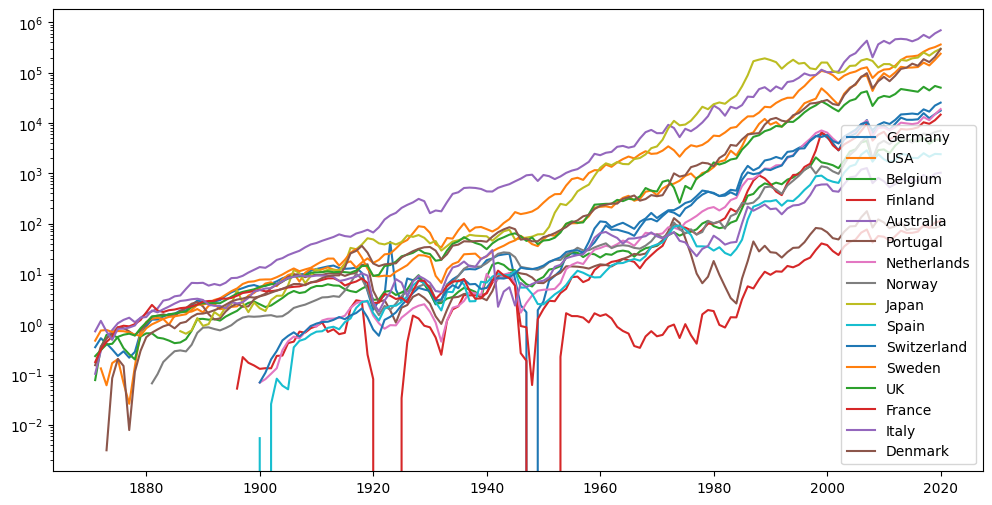

In [6]:
# make some plots to check the data looks correct
# cumulative returns

cum_eq_tr_usd = jst_with_c_ret.filter(pl.col("eq_tr").is_not_null()).with_columns(
    ((pl.col("eq_tr_usd")+1).cum_prod()-1).over("country").alias("cum_eq_tr_usd"),
    "year",
    "country"
)

fig, ax = plt.subplots(figsize=(12, 6))

for country in cum_eq_tr_usd["country"].unique():
    # if country == "Germany":
    #     continue
    country_data = cum_eq_tr_usd.filter(pl.col("country") == country)
    ax.plot(country_data["year"], country_data["cum_eq_tr_usd"], label=country)

ax.legend()
ax.set_yscale("log")
cum_eq_tr_usd.write_csv("data/cum_eq_tr_usd.csv")

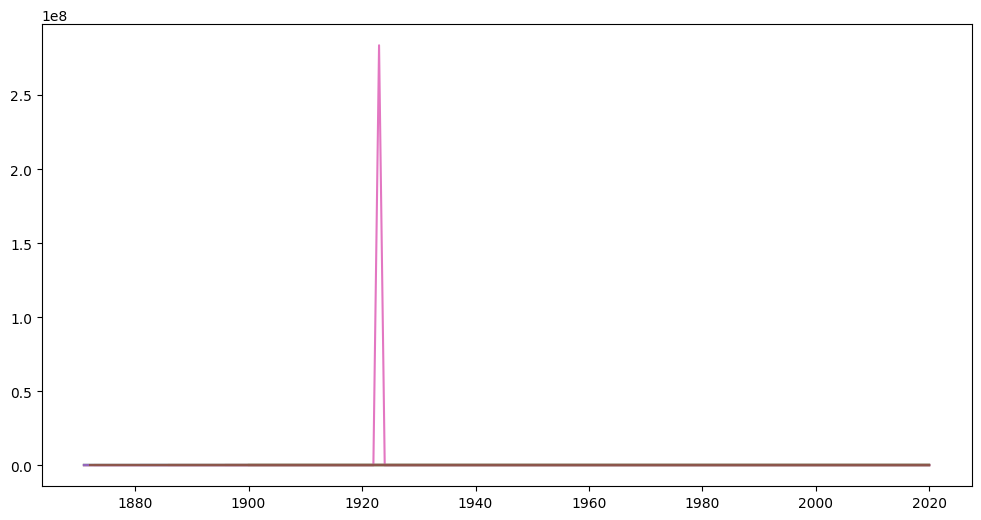

In [176]:
fig, ax = plt.subplots(figsize=(12, 6))
for country in cum_eq_tr_usd["country"].unique():
    # if country == "Germany":
    #     continue
    country_data = cum_eq_tr_usd.filter(pl.col("country") == country)
    ax.plot(country_data["year"], country_data["xrusd_return"], label=country)

In [188]:
wdi_jst_country_mapping = pl.DataFrame(
    list(
        {
            "Australia": "Australia",
            "Belgium": "Belgium",
            "Canada": "Canada",
            "Denmark": "Denmark",
            "Finland": "Finland",
            "France": "France",
            "Germany": "Germany",
            "Ireland": "Ireland",
            "Italy": "Italy",
            "Japan": "Japan",
            "Netherlands": "Netherlands",
            "Norway": "Norway",
            "Portugal": "Portugal",
            "Spain": "Spain",
            "Sweden": "Sweden",
            "Switzerland": "Switzerland",
            "UK": "United Kingdom",
            "USA": "United States",
        }.items()
    ),
    orient="row",
    schema=["jst_country_name", "wdi_country_name"],
)

wdi_mkt_cap_unpivoted = (
    wdi_mkt_cap
    .select(*[c for c in wdi_mkt_cap.columns if c])
    .unpivot(
        index=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        variable_name="year",
        value_name="mkt_cap_pct_gdp",
    )
    .with_columns(
        pl.col("year").cast(pl.Int64),
        pl.col("mkt_cap_pct_gdp").cast(pl.Float64, strict=False)/100,
    )
    .filter(pl.col("mkt_cap_pct_gdp").is_not_null())
)
wdi_mkt_cap_country_mapped = (
    wdi_mkt_cap_unpivoted
    .join(
        wdi_jst_country_mapping,
        left_on="Country Name",
        right_on="wdi_country_name",
        how="inner",
    )
)





jst_with_mkt_cap = (
    jst_with_c_ret
    .join(
        wdi_mkt_cap_country_mapped.select("jst_country_name", "year", "mkt_cap_pct_gdp"),
        left_on=["country", "year"],
        right_on=["jst_country_name", "year"],
        how="left",
    )
    .select(
        "country",
        "year",
        "eq_tr",
        "xrusd_return",
        "eq_tr_usd",
        "mkt_cap_pct_gdp",
        "gdp",
        "xrusd",
    )
    .with_columns(
        (pl.col("mkt_cap_pct_gdp") * pl.col("gdp")).alias("mkt_cap")
    )
)
jst_with_mkt_cap.write_csv("data/jst_with_mkt_cap.csv")

In [189]:
# back-imputation of market cap for missing years using equity returns
# Strategy: iteratively fill backwards one year at a time

jst_sorted = jst_with_mkt_cap.sort("country", "year")

# Create a working copy of market cap that we'll fill in
df = jst_sorted.with_columns(pl.col("mkt_cap").alias("mkt_cap_imputed"))

# Iterate backwards through years, filling in missing values
# mkt_cap_t = mkt_cap_{t+1} / (1 + return_{t+1})
for _ in range(200):  # Max iterations to fill gaps (adjust if needed)
    df = df.with_columns([
        pl.when(pl.col("mkt_cap_imputed").is_null())
        .then(
            pl.col("mkt_cap_imputed").shift(-1).over("country") / 
            (1 + pl.col("eq_tr_usd").shift(-1).over("country"))
        )
        .otherwise(pl.col("mkt_cap_imputed"))
        .alias("mkt_cap_imputed")
    ])
    
    # Check if we're done (no more nulls)
    if df["mkt_cap_imputed"].null_count() == 0:
        break

jst_with_imputed_mkt_cap = df
jst_with_imputed_mkt_cap.write_csv("data/jst_with_imputed_mkt_cap.csv")
jst_with_imputed_mkt_cap

country,year,eq_tr,xrusd_return,eq_tr_usd,mkt_cap_pct_gdp,gdp,xrusd,mkt_cap,mkt_cap_imputed
str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""Australia""",1871,0.110193,0.005996,0.103576,null,211.56,0.369146,null,2.759467
"""Australia""",1872,0.176749,0.00025,0.176455,null,227.4,0.369239,null,3.246389
"""Australia""",1873,0.151686,-0.018508,0.173404,null,266.54,0.362405,null,3.809325
"""Australia""",1874,0.191481,0.027093,0.160052,null,287.58,0.372223,null,4.419014
"""Australia""",1875,0.124408,-0.030352,0.159605,null,300.74,0.360926,null,5.124309
…,…,…,…,…,…,…,…,…,…
"""USA""",2016,0.036493,0.0,0.036493,1.463067,18695.1,1.0,27352.184857,27352.184857
"""USA""",2017,0.193025,0.0,0.193025,1.649132,19479.6,1.0,32124.43538,32124.43538
"""USA""",2018,0.142075,0.0,0.142075,1.482308,20527.2,1.0,30427.63071,30427.63071


(-1.0, 1.0)

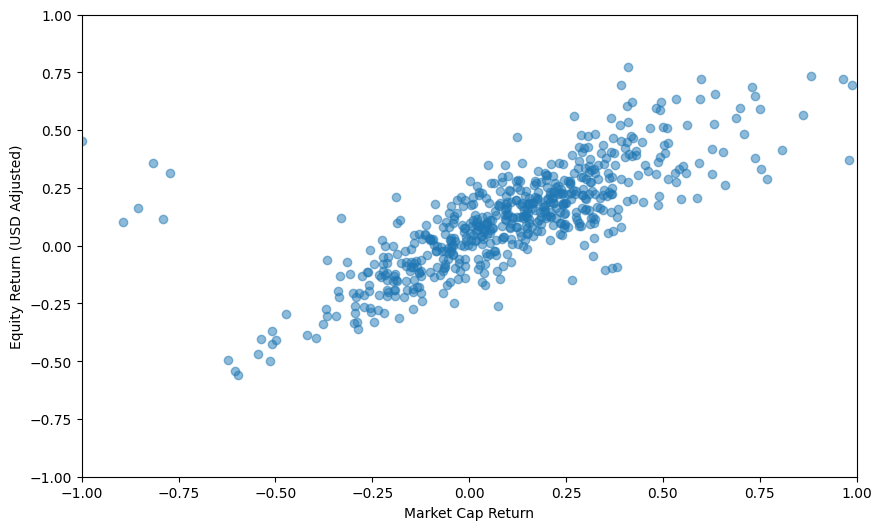

In [193]:
# see how well returns correlate with market cap change
return_data = (
    jst_with_mkt_cap
    .sort("country", "year")
    .with_columns(
        pl.col("mkt_cap").pct_change().over("country").alias("mkt_cap_return")
    )
    .filter(pl.col("mkt_cap_return") < 100)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(return_data["mkt_cap_return"], return_data["eq_tr"], alpha=0.5)
ax.set_xlabel("Market Cap Return")
ax.set_ylabel("Equity Return (USD Adjusted)")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

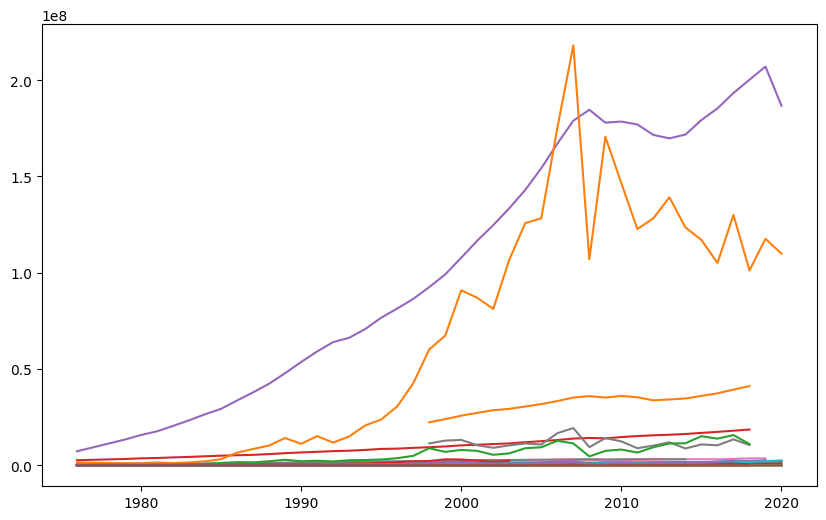

In [183]:
fig, ax = plt.subplots(figsize=(10, 6))
# for each country, plot a line of gdp over time
for country in return_data["country"].unique():
    country_data = return_data.filter(pl.col("country") == country)
    ax.plot(country_data["year"], country_data["gdp"], label=country)
# now do market cap
for country in return_data["country"].unique():
    country_data = return_data.filter(pl.col("country") == country)
    ax.plot(country_data["year"], country_data["mkt_cap"], label=country)